# Indexación de Bragg peaks a nivel BVM — Demo 256×256

Este notebook expone los índices `(h, k)` que py4DSTEM 0.14.19 ya calcula internamente sobre el
**BVM calibrado** (`braggpeaks.histogram(mode="cal")`), reutilizando exactamente las mismas funciones
de Fast4D que usa el paso *Basis* de la GUI:

- `pipeline.load_braggpeaks_file` — carga Path A (solo `braggpeaks.h5`, sin datacube).
- Rehidratación de calibración (origin, Q pixel size, QR rotation) desde `strain_manifest.json` de un run real.
- `pipeline.setup_basis_step` → `StrainMap.choose_basis_vectors`, que internamente ejecuta
  `index_bragg_directions` y deja los `(h, k)` en `strainmap.braggdirections`.

**No se escribe ningún indexador desde cero, no se usa GPA y no se re-tunea ningún parámetro**: todo
sale del manifest del run previo, que además provee los vectores `g1_qxy` / `g2_qxy` como referencia
de regresión (notebook = GUI).

Kernel: `py4dstem-01419` (py4DSTEM 0.14.19).

## 1. Setup

Rutas de entrada (solo lectura), carpeta de salida y `sys.path` hacia la raíz del worktree para
importar `pipeline` / `state` de Fast4D.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Localizar la raíz del worktree (donde vive pipeline.py) subiendo desde el cwd
ROOT = Path.cwd().resolve()
while not (ROOT / "pipeline.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("No se encontró pipeline.py — ejecuta el notebook dentro del worktree de Fast4D.")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pipeline as pl
from state import WorkflowState

import py4DSTEM
print("py4DSTEM:", py4DSTEM.__version__)
print("ROOT:", ROOT)

# Datos del Demo (solo lectura) y salida del notebook
BRAGGPEAKS_PATH = Path(r"C:\Users\jtapiaca.ASURITE\Desktop\Demo\256x256_Demo_braggpeaks.h5")
MANIFEST_PATH = Path(r"C:\Users\jtapiaca.ASURITE\Desktop\Demo\256x256_Demo\data\strain_manifest.json")
OUTPUT_DIR = ROOT / "notebooks" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
EXPECTED_RSHAPE = tuple(int(v) for v in manifest["image_shape"])
print("Rshape esperado:", EXPECTED_RSHAPE)
print("q_pixel_size del manifest:", manifest["q_pixel_size"], manifest["q_pixel_units"])

cupyx.jit.rawkernel is experimental. The interface can change in the future.



Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md



py4DSTEM: 0.14.19
ROOT: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook
Rshape esperado: (256, 256)
q_pixel_size del manifest: 0.013823759961459165 A^-1


## 2. Cargar braggpeaks (Path A)

`pipeline.load_braggpeaks_file` es la misma función que llama el paso *Basis* de Fast4D: prueba los
datapaths EMD conocidos, valida el `Rshape` esperado y hace `setcal()`. Inspeccionamos formas,
`calstate` y el número de picos por posición de scan.

Nota: recién cargado el archivo, `calstate` está todo en `False`, así que el BVM `cal` es idéntico al
`raw` — la diferencia aparece en la sección 3 al rehidratar la calibración.

Reading PointListArray:   0%|          | 0/65536 [00:00<?, ?PointList/s]

Reading PointListArray:   3%|▎         | 2116/65536 [00:00<00:03, 19345.57PointList/s]

Reading PointListArray:   6%|▋         | 4155/65536 [00:00<00:03, 19933.80PointList/s]

Reading PointListArray:  10%|▉         | 6241/65536 [00:00<00:02, 20310.66PointList/s]

Reading PointListArray:  13%|█▎        | 8404/65536 [00:00<00:02, 20818.87PointList/s]

...

Reading PointListArray:  93%|█████████▎| 60849/65536 [00:03<00:00, 17605.22PointList/s]

Reading PointListArray:  96%|█████████▌| 62684/65536 [00:03<00:00, 17808.87PointList/s]

Reading PointListArray:  98%|█████████▊| 64473/65536 [00:03<00:00, 17782.94PointList/s]

Reading PointListArray: 100%|██████████| 65536/65536 [00:03<00:00, 18512.23PointList/s]

Loaded full-scan braggpeaks from: C:\Users\jtapiaca.ASURITE\Desktop\Demo\256x256_Demo_braggpeaks.h5
braggpeaks Rshape: (256, 256) | calstate={'center': False, 'ellipse': False, 'pixel': False, 'rotate': False}
Rshape : (256, 256)
Qshape : (256, 256)
calstate: {'center': False, 'ellipse': False, 'pixel': False, 'rotate': False}
picos/posición: min=6  max=50  media=38.55  total=2526182


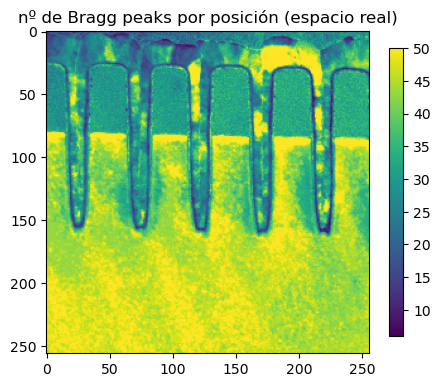

In [2]:
bp = pl.load_braggpeaks_file(BRAGGPEAKS_PATH, expected_rshape=EXPECTED_RSHAPE, log=print)
print("Rshape :", tuple(int(v) for v in bp.Rshape))
print("Qshape :", tuple(int(v) for v in bp.Qshape))
print("calstate:", bp.calstate)

# nº de picos detectados por posición de scan (sobre los vectores raw)
pla = bp.raw
counts = np.empty(tuple(int(v) for v in bp.Rshape), dtype=int)
for rx in range(counts.shape[0]):
    for ry in range(counts.shape[1]):
        counts[rx, ry] = len(pla[rx, ry].data)
print(f"picos/posición: min={counts.min()}  max={counts.max()}  media={counts.mean():.2f}  total={counts.sum()}")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(counts, cmap="viridis")
ax.set_title("nº de Bragg peaks por posición (espacio real)")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

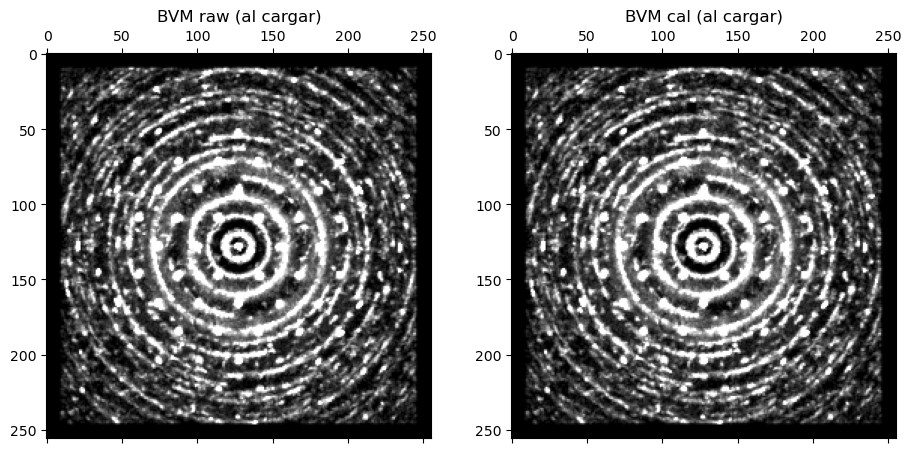

máx |raw − cal| al cargar: 0.0 (esperado 0: aún no hay calibración)


In [3]:
# BVM raw vs cal al cargar (sin calibración aplicada todavía: deben ser idénticos)
bvm_raw_load = bp.histogram(mode="raw", sampling=1)
bvm_cal_load = bp.histogram(mode="cal", sampling=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
py4DSTEM.show(bvm_raw_load, figax=(fig, axes[0]), title="BVM raw (al cargar)", **pl.ORIGIN_BVM_VIS_PARAMS)
py4DSTEM.show(bvm_cal_load, figax=(fig, axes[1]), title="BVM cal (al cargar)", **pl.ORIGIN_BVM_VIS_PARAMS)
plt.show()

diff = float(np.max(np.abs(np.asarray(bvm_raw_load.data, dtype=float) - np.asarray(bvm_cal_load.data, dtype=float))))
print("máx |raw − cal| al cargar:", diff, "(esperado 0: aún no hay calibración)")

## 3. Rehidratar calibración desde `strain_manifest.json`

Replicamos la cadena que `fast_batch._apply_calibration` ejecuta desde JSON, usando las funciones de
`pipeline` sobre un `WorkflowState`:

1. `set_origin_center_guess` + `run_origin_correction_step` — origin `(127, 127)` del manifest,
   `measure_origin` → `fit_origin` → `setcal`.
2. `set_q_pixel_size_step` — `q_pixel_size` del manifest.
3. `update_strain_basis_params` — parámetros de `choose_basis_vectors`, QR rotation 135° y los índices
   manuales `index_origin=0, index_g1=7, index_g2=4` del run real.

Ningún valor se inventa: todos salen del manifest. (El ROI del manifest no se aplica: requiere
datacube — Path B — y no afecta al BVM ni a la elección de base.)

center_guess set to native (y,x)=(127, 127), sampling=1


Running measure_origin(center_guess GUI y,x=(127, 127) → py4DSTEM qx,qy=(127, 127))...


Running fit_origin()...


Origin correction complete. calstate={'center': True, 'ellipse': False, 'pixel': False, 'rotate': False}
Set Q pixel size: 0.0138238 A^-1/px | calstate={'center': True, 'ellipse': False, 'pixel': True, 'rotate': False}


BraggVectors( A (np.int64(256), np.int64(256))-shaped array of lists of bragg vectors )

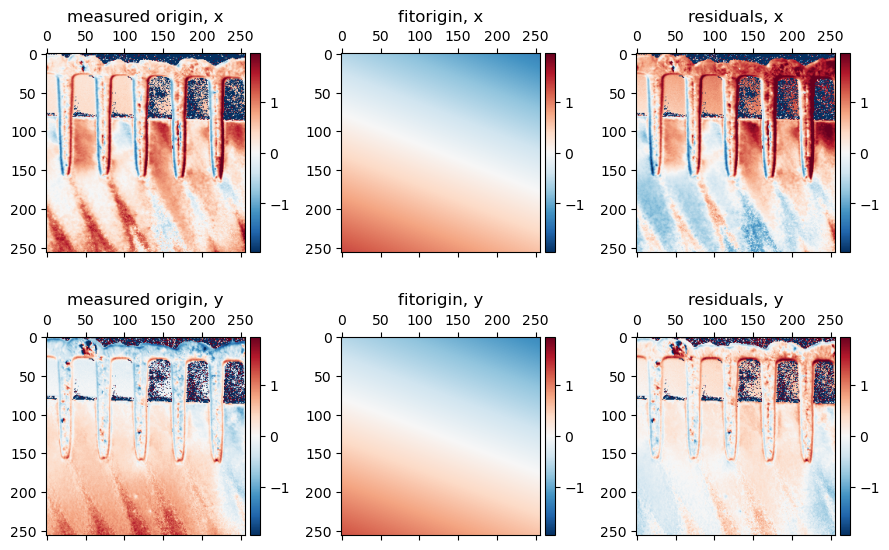

In [4]:
state = WorkflowState()
state.braggpeaks = bp
state.braggpeaks_path = BRAGGPEAKS_PATH

# 3.1 Origin: center guess (y, x) del manifest + measure/fit/setcal
oy, ox = (int(v) for v in manifest["origin_xy"])
pl.set_origin_center_guess(state, (oy, ox), sampling=1, log=print)
origin_result = pl.run_origin_correction_step(state, log=print)

# 3.2 Q pixel size
pl.set_q_pixel_size_step(state, float(manifest["q_pixel_size"]), units=str(manifest["q_pixel_units"]), log=print)

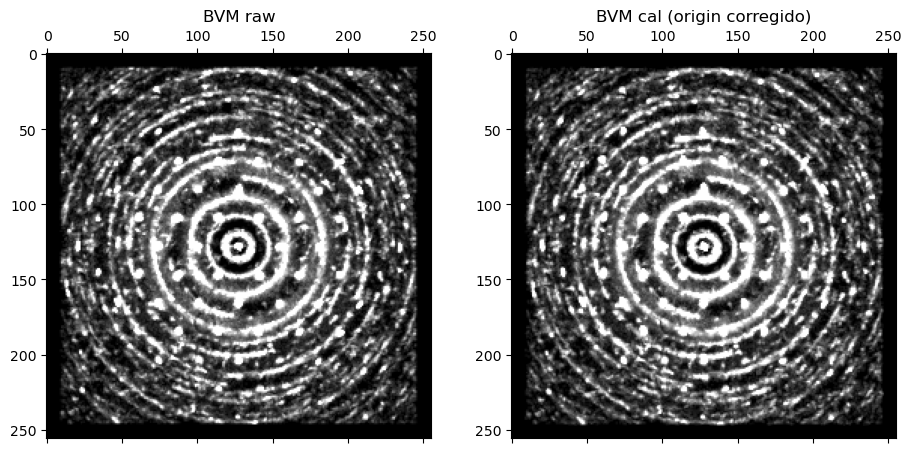

In [5]:
# BVM raw vs cal DESPUÉS de la corrección de origin: ahora sí se ve qué cambia la calibración
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
py4DSTEM.show(origin_result["bvm_raw"], figax=(fig, axes[0]), title="BVM raw", **pl.ORIGIN_BVM_VIS_PARAMS)
py4DSTEM.show(origin_result["bvm_centered"], figax=(fig, axes[1]), title="BVM cal (origin corregido)", **pl.ORIGIN_BVM_VIS_PARAMS)
plt.show()

In [6]:
# 3.3 Parámetros de basis + QR rotation del manifest (incluye los índices manuales del run real)
sbp = manifest["strain_basis_params"]
cbv = sbp["choose_basis_vectors"]
vis = cbv.get("vis_params", {})

pl.update_strain_basis_params(
    state,
    min_spacing=int(cbv["minSpacing"]),
    min_absolute_intensity=int(cbv["minAbsoluteIntensity"]),
    max_num_peaks=int(cbv["maxNumPeaks"]),
    edge_boundary=int(cbv["edgeBoundary"]),
    vmin=float(vis.get("vmin", 0.0)),
    vmax=float(vis.get("vmax", 0.995)),
    qr_rotation=float(sbp.get("qr_rotation", 0.0)),
    qr_flip=bool(sbp.get("qr_flip", False)),
    manual_enabled=bool(sbp.get("manual_enabled", False)),
    index_origin=int(cbv.get("index_origin", 0)),
    index_g1=int(cbv.get("index_g1", 0)),
    index_g2=int(cbv.get("index_g2", 0)),
    log=print,
)
print("calstate tras rehidratar:", bp.calstate)

Updated strain basis params. QR_rotation=135.0, QR_flip=False
calstate tras rehidratar: {'center': True, 'ellipse': False, 'pixel': True, 'rotate': True}


## 4. Basis setup + test de regresión g1/g2 vs manifest

`pipeline.setup_basis_step` construye `py4DSTEM.StrainMap(braggvectors=...)` y llama
`choose_basis_vectors` con los parámetros ya cargados. **Test de regresión clave**: los vectores
`g1`/`g2` elegidos por el notebook deben reproducir los `g1_qxy`/`g2_qxy` que el run real de la GUI
guardó en el manifest (tolerancia 1e-3 px). Si esto pasa, notebook = GUI.

Interactive basis calibration setup complete.
g0 (pico origin en el BVM): (127.2882, 127.8239)
g1 notebook: [-26.87662198  26.86497363]   manifest: [-26.87662198  26.86497363]   delta: [0. 0.]
g2 notebook: [-18.54119073 -18.87934576]   manifest: [-18.54119073 -18.87934576]   delta: [0. 0.]

OK — g1/g2 reproducen g1_qxy/g2_qxy del manifest dentro de 0.001 px (notebook = GUI).


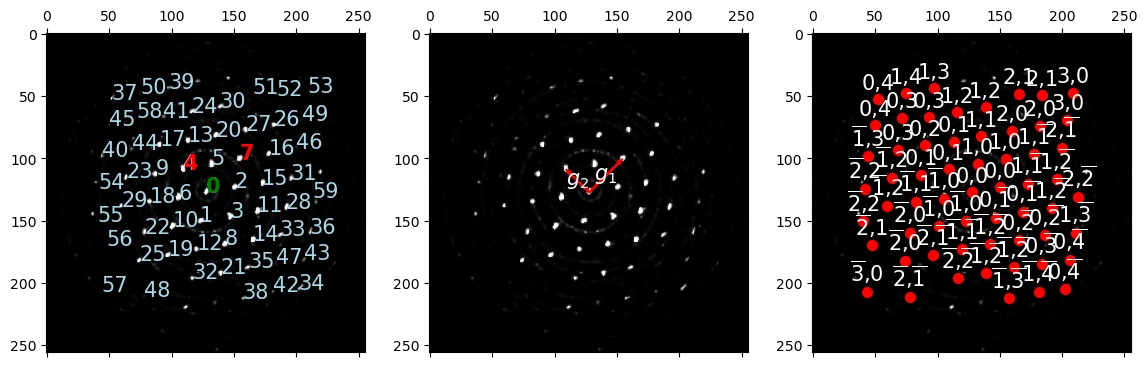

In [7]:
strainmap = pl.setup_basis_step(state, log=print)

g1 = np.asarray(strainmap.g1, dtype=float)
g2 = np.asarray(strainmap.g2, dtype=float)
g1_ref = np.asarray(sbp["g1_qxy"], dtype=float)
g2_ref = np.asarray(sbp["g2_qxy"], dtype=float)

print(f"g0 (pico origin en el BVM): {tuple(round(float(v), 4) for v in strainmap.g0)}")
print(f"g1 notebook: {g1}   manifest: {g1_ref}   delta: {g1 - g1_ref}")
print(f"g2 notebook: {g2}   manifest: {g2_ref}   delta: {g2 - g2_ref}")

TOL_PX = 1e-3
assert np.allclose(g1, g1_ref, atol=TOL_PX), f"g1 no reproduce g1_qxy del manifest (tol {TOL_PX} px)"
assert np.allclose(g2, g2_ref, atol=TOL_PX), f"g2 no reproduce g2_qxy del manifest (tol {TOL_PX} px)"
print(f"\nOK — g1/g2 reproducen g1_qxy/g2_qxy del manifest dentro de {TOL_PX} px (notebook = GUI).")

## 5. Indexación BVM: `strainmap.braggdirections` → (h, k)

En py4DSTEM 0.14.19 los `(h, k)` a nivel BVM ya están calculados: `choose_basis_vectors` ejecuta
internamente `index_bragg_directions` y guarda el resultado en `strainmap.braggdirections`
(campos `qx, qy, g1_ind, g2_ind`, con `qx/qy` **relativos al origin calibrado**). Fast4D los usa para
strain pero nunca los expone — aquí los sacamos a la luz.

Verificaciones:
- El pico más cercano al origin indexa como `(0, 0)`.
- Los picos g1 y g2 indexan como `(1, 0)` y `(0, 1)` con residual pequeño.
- Para cada máximo, residual `|g_medido − (h·g1 + k·g2)|` contra el `max_peak_spacing` del manifest
  (2.0 px). Los máximos que no pertenecen a la red elegida (otro grano / ruido) exceden el umbral —
  son exactamente los que `fit_basis_vectors` descartaría vía `max_peak_spacing`.

In [8]:
bd = strainmap.braggdirections
rec = np.asarray(bd.data)
print("campos:", rec.dtype.names, "| n máximos del BVM:", len(rec))

qx = rec["qx"].astype(float)   # relativo al origin calibrado
qy = rec["qy"].astype(float)
h = rec["g1_ind"].astype(int)
k = rec["g2_ind"].astype(int)

# Residual de red: |g_medido − (h·g1 + k·g2)|
pred = h[:, None] * g1[None, :] + k[:, None] * g2[None, :]
residual = np.hypot(qx - pred[:, 0], qy - pred[:, 1])

MAX_PEAK_SPACING = float(manifest["strain_params"]["set_max_peak_spacing"]["max_peak_spacing"])
indexed_ok = residual < MAX_PEAK_SPACING
print(f"max_peak_spacing (manifest): {MAX_PEAK_SPACING} px")
print(f"máximos consistentes con la red g1/g2: {int(indexed_ok.sum())}/{len(rec)}")

# Verificación 1: el origin indexa como (0,0)
i0 = int(np.argmin(np.hypot(qx, qy)))
print(f"pico origin : q=({qx[i0]:+.3f}, {qy[i0]:+.3f}) -> (h,k)=({h[i0]},{k[i0]})  residual={residual[i0]:.3f} px")
assert (h[i0], k[i0]) == (0, 0), "el pico del origin no indexa como (0,0)"
assert residual[i0] < MAX_PEAK_SPACING

# Verificación 2: g1 -> (1,0) y g2 -> (0,1)
i1 = int(np.argmin(np.hypot(qx - g1[0], qy - g1[1])))
i2 = int(np.argmin(np.hypot(qx - g2[0], qy - g2[1])))
print(f"pico g1     : q=({qx[i1]:+.3f}, {qy[i1]:+.3f}) -> (h,k)=({h[i1]},{k[i1]})  residual={residual[i1]:.3f} px")
print(f"pico g2     : q=({qx[i2]:+.3f}, {qy[i2]:+.3f}) -> (h,k)=({h[i2]},{k[i2]})  residual={residual[i2]:.3f} px")
assert (h[i1], k[i1]) == (1, 0) and residual[i1] < MAX_PEAK_SPACING, "g1 no indexa como (1,0)"
assert (h[i2], k[i2]) == (0, 1) and residual[i2] < MAX_PEAK_SPACING, "g2 no indexa como (0,1)"

n_out = int((~indexed_ok).sum())
if n_out:
    print(f"máximos fuera de la red (residual >= {MAX_PEAK_SPACING} px): {n_out} — "
          "fit_basis_vectors los descartaría vía max_peak_spacing")
print("\nOK — verificaciones de indexación superadas.")

campos: ('qx', 'qy', 'g1_ind', 'g2_ind') | n máximos del BVM: 60
max_peak_spacing (manifest): 2.0 px
máximos consistentes con la red g1/g2: 22/60
pico origin : q=(-0.271, +0.204) -> (h,k)=(0,0)  residual=0.339 px
pico g1     : q=(-27.147, +27.069) -> (h,k)=(1,0)  residual=0.339 px
pico g2     : q=(-18.812, -18.676) -> (h,k)=(0,1)  residual=0.339 px
máximos fuera de la red (residual >= 2.0 px): 38 — fit_basis_vectors los descartaría vía max_peak_spacing

OK — verificaciones de indexación superadas.


In [9]:
# Tabla indexada: coordenadas relativas y absolutas (px del BVM), (h,k), residual e intensidad BVM
bvm_cal = np.asarray(strainmap.bvm.data, dtype=float)
origin_q = np.asarray(strainmap.origin, dtype=float)
print("origin calibrado (px BVM):", origin_q)

qx_abs = qx + origin_q[0]
qy_abs = qy + origin_q[1]
iqx = np.clip(np.round(qx_abs).astype(int), 0, bvm_cal.shape[0] - 1)
iqy = np.clip(np.round(qy_abs).astype(int), 0, bvm_cal.shape[1] - 1)
bvm_intensity = bvm_cal[iqx, iqy]

table = pd.DataFrame({
    "qx": qx, "qy": qy,
    "qx_abs_px": qx_abs, "qy_abs_px": qy_abs,
    "h": h, "k": k,
    "residual_px": residual,
    "bvm_intensity": bvm_intensity,
    "indexed_ok": indexed_ok,
}).sort_values("bvm_intensity", ascending=False).reset_index(drop=True)
table.head(15)

origin calibrado (px BVM): [127.55905811 127.6201057 ]


,qx,qy,qx_abs_px,qy_abs_px,h,k,residual_px,bvm_intensity,indexed_ok
0,-0.270860,0.203840,127.288198,127.823946,0,0,0.338993,4.834752e+06,True
1,23.129823,-4.753433,150.688881,122.866672,-1,0,22.426741,2.769586e+06,False
2,-4.319725,22.899936,123.239333,150.520042,0,0,23.303800,2.565778e+06,False
3,20.151851,19.214388,147.710909,146.834494,0,-1,1.645138,2.180513e+06,True
4,-23.136570,4.486366,104.422488,132.106472,1,0,22.688985,1.870917e+06,False
5,5.015152,-22.422653,132.574210,105.197452,-1,0,22.308252,1.865328e+06,False
6,-18.812051,-18.675506,108.747007,108.944600,0,1,0.338993,1.832058e+06,True
7,-27.147482,27.068813,100.411576,154.688919,1,0,0.338993,1.730195e+06,True
8,41.477684,14.692686,169.036742,142.312792,-1,-2,22.800041,1.602306e+06,False
9,-14.414026,-40.705071,113.145032,86.915035,0,1,22.212514,1.486182e+06,False


In [10]:
# Paridad opcional con la pipeline de strain (per-scan-position; lenta en 256x256).
# El objetivo BVM-level de este notebook NO la necesita: los (h,k) ya están en braggdirections.
RUN_FIT_PARITY = False
if RUN_FIT_PARITY:
    strainmap.set_max_peak_spacing(MAX_PEAK_SPACING)
    strainmap.fit_basis_vectors()
    print("bragg_vectors_indexed:", strainmap.bragg_vectors_indexed)
    print("g1g2_map:", strainmap.g1g2_map)
else:
    print("RUN_FIT_PARITY=False — omitido (activa el flag para paridad con la pipeline de strain).")

RUN_FIT_PARITY=False — omitido (activa el flag para paridad con la pipeline de strain).


## 6. Visualización: BVM calibrado con etiquetas (h, k)

Overlay del BVM calibrado con cada máximo etiquetado y las flechas g1/g2 desde el origin
(comparable con `figures/basis.png` del run previo). Convención py4DSTEM: `qx` = eje vertical,
`qy` = eje horizontal.

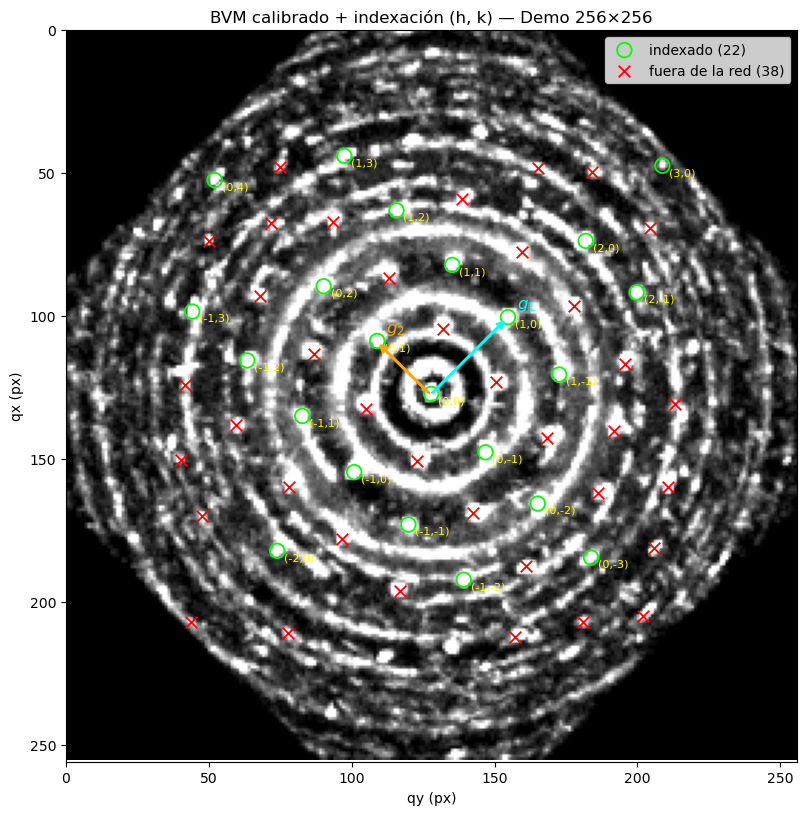

In [11]:
disp = np.power(np.clip(bvm_cal, 0.0, 2e3), 0.5)  # misma escala que la GUI (power 0.5, vmax 2e3)

fig, ax = plt.subplots(figsize=(9.5, 9.5))
ax.imshow(disp, cmap="gray")

ok = indexed_ok
ax.scatter(qy_abs[ok], qx_abs[ok], s=110, facecolors="none", edgecolors="lime",
           linewidths=1.3, label=f"indexado ({int(ok.sum())})")
if (~ok).any():
    ax.scatter(qy_abs[~ok], qx_abs[~ok], s=70, marker="x", c="red",
               linewidths=1.3, label=f"fuera de la red ({int((~ok).sum())})")
for i in np.flatnonzero(ok):
    ax.annotate(f"({h[i]},{k[i]})", (qy_abs[i], qx_abs[i]), xytext=(5, -7),
                textcoords="offset points", color="yellow", fontsize=8)

for gvec, name, color in ((g1, "$g_1$", "cyan"), (g2, "$g_2$", "orange")):
    ax.annotate("", xy=(origin_q[1] + gvec[1], origin_q[0] + gvec[0]),
                xytext=(origin_q[1], origin_q[0]),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.2))
    ax.annotate(name, (origin_q[1] + gvec[1], origin_q[0] + gvec[0]), xytext=(7, 7),
                textcoords="offset points", color=color, fontsize=12, fontweight="bold")

ax.set_title("BVM calibrado + indexación (h, k) — Demo 256×256")
ax.set_xlabel("qy (px)")
ax.set_ylabel("qx (px)")
ax.legend(loc="upper right")
ax.set_xlim(0, bvm_cal.shape[1])
ax.set_ylim(bvm_cal.shape[0], 0)
overlay_fig = fig
plt.show()

## 7. Export

Tabla indexada a CSV y figura overlay a PNG en `notebooks/output/` (carpeta ignorada por git).

In [12]:
csv_path = OUTPUT_DIR / "indexed_bvm_peaks.csv"
png_path = OUTPUT_DIR / "bvm_indexed_overlay.png"

table.to_csv(csv_path, index=False)
overlay_fig.savefig(png_path, dpi=200, bbox_inches="tight")

print(f"CSV: {csv_path}  ({csv_path.stat().st_size} bytes, {len(table)} filas)")
print(f"PNG: {png_path}  ({png_path.stat().st_size} bytes)")
print("\nListo. Contrato de salida para la futura pipeline.index_bvm_peaks_step(state):")
print("  entrada : state con braggpeaks calibrados + strain_basis_params (como el paso Basis)")
print("  salida  : tabla (qx, qy, h, k, residual_px, bvm_intensity, indexed_ok) + overlay PNG")

CSV: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook\notebooks\output\indexed_bvm_peaks.csv  (7424 bytes, 60 filas)
PNG: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook\notebooks\output\bvm_indexed_overlay.png  (299991 bytes)

Listo. Contrato de salida para la futura pipeline.index_bvm_peaks_step(state):
  entrada : state con braggpeaks calibrados + strain_basis_params (como el paso Basis)
  salida  : tabla (qx, qy, h, k, residual_px, bvm_intensity, indexed_ok) + overlay PNG


## 8. Comparación con el indexador FFT del proyecto GPA

El notebook `GPA/notebooks/FFT_indexing.ipynb` indexa spots de la FFT de una imagen HRTEM con
`gpa.indexing`: detección de spots → **RANSAC** (`fit_lattice_ransac`) que encuentra la base recíproca
automáticamente → asignación de índices enteros resolviendo `B·(m,n) ≈ g` y redondeando — el mismo
principio que `index_bragg_directions` de py4DSTEM, con dos diferencias de diseño:

| | Fast4D / py4DSTEM (este notebook) | GPA `fit_lattice_ransac` |
|---|---|---|
| Espacio | BVM del scan 4DSTEM (difracción) | FFT de una imagen HRTEM |
| Base g1/g2 | elegida por índices del run real (manifest) | encontrada automáticamente (RANSAC + reducción de Gauss) |
| Asignación (h,k) | `index_bragg_directions`: resolver + redondear | idéntico: resolver + redondear |
| Filtro de pertenencia | residual < `max_peak_spacing` | residual < `tol` (inliers RANSAC) |
| Extra | — | fase cristalina: (hkl) 3D, zone axis, d-spacings vs teoría |

Como los datos de ese notebook son otros (Si FIB, 4096²), la comparación justa es **algorítmica**:
ejecutamos su motor RANSAC sobre nuestros mismos 60 máximos del BVM y comparamos la base recuperada,
los (h,k) por pico y el conjunto de inliers contra py4DSTEM.
Solo se cargan `gpa/indexing/models.py` y `lattice.py` (numpy puro), sin importar el paquete GPA completo.

### Unidades físicas: el contrato px ↔ Å⁻¹

El flujo FFT del GPA trabaja en nm⁻¹ porque la imagen trae `pixel_size_nm` y de ahí sale
`dk = 1/(N·px)`. En Fast4D el equivalente **no se inventa**: vive en el estado de calibración de los
braggpeaks — `braggpeaks.calibration.get_Q_pixel_size()` / `get_Q_pixel_units()` (aquí Å⁻¹/px,
aplicado en la sección 3 con `set_q_pixel_size_step` desde el manifest). Ese es el único puente que
se necesita:

- coordenadas físicas de cada máximo: `g[Å⁻¹] = q[px BVM cal] × Q_pixel_size`
- tolerancia física: `tol[Å⁻¹] = max_peak_spacing[px] × Q_pixel_size` (py4DSTEM define
  `max_peak_spacing` en px del BVM calibrado)
- d-spacing directo: `d[Å] = 1/|g|`

El RANSAC es agnóstico a la escala (resolver `B·(m,n) ≈ g` + redondear es invariante ante un factor
global), así que corre igual en Å⁻¹; la ganancia es que la base, los residuales y la tabla salen ya
en unidades físicas, que es lo que una futura `pipeline.index_bvm_peaks_step` debe reportar.
Nota: el campo del modelo GPA se llama `gx_nm_inv` pero es solo un nombre — le pasamos Å⁻¹ y
documentamos las unidades en la salida. (La calibración de elipse no está hecha en este run
— `ellipse_done: false` — así que la escala isotrópica única es correcta.)

In [13]:
# Cargar el indexador RANSAC del proyecto GPA sin ejecutar gpa/__init__.py (evita deps de GUI)
import types
import importlib.util

GPA_ROOT = Path(r"C:\Users\jtapiaca.ASURITE\AI Projects\GPA")

def _load_gpa_indexing(root: Path):
    pkg = types.ModuleType("gpaidx")
    pkg.__path__ = [str(root / "gpa" / "indexing")]
    sys.modules["gpaidx"] = pkg
    mods = {}
    for name in ("models", "lattice"):
        spec = importlib.util.spec_from_file_location(f"gpaidx.{name}", root / "gpa" / "indexing" / f"{name}.py")
        mod = importlib.util.module_from_spec(spec)
        sys.modules[f"gpaidx.{name}"] = mod
        spec.loader.exec_module(mod)
        mods[name] = mod
    return mods

_gpa = _load_gpa_indexing(GPA_ROOT)
DetectedSpot = _gpa["models"].DetectedSpot
fit_lattice_ransac = _gpa["lattice"].fit_lattice_ransac

# --- Puente de unidades: la calibración de los braggpeaks es la fuente de verdad ---
Q_PIXEL = float(bp.calibration.get_Q_pixel_size())      # Å^-1 / px (aplicado en sección 3)
Q_UNITS = str(bp.calibration.get_Q_pixel_units())
assert np.isclose(Q_PIXEL, float(manifest["q_pixel_size"])), "calstate != manifest (q_pixel)"
print(f"Q_pixel_size (calibración): {Q_PIXEL:.6f} {Q_UNITS}/px")

# Coordenadas físicas de los 60 máximos (relativas al origin) y tolerancia física
gx_A = qx * Q_PIXEL          # Å^-1
gy_A = qy * Q_PIXEL
TOL_A = MAX_PEAK_SPACING * Q_PIXEL
print(f"tolerancia: {MAX_PEAK_SPACING} px = {TOL_A:.5f} Å⁻¹")

# DetectedSpot en Å^-1 (el campo se llama *_nm_inv pero el algoritmo es agnóstico a la unidad);
# score = intensidad del BVM. row/col se mantienen en px absolutos para trazabilidad.
spots = [
    DetectedSpot(row=float(xa), col=float(ya), score=float(s), gx_nm_inv=float(gx), gy_nm_inv=float(gy))
    for xa, ya, gx, gy, s in zip(qx_abs, qy_abs, gx_A, gy_A, bvm_intensity)
]

lat = fit_lattice_ransac(
    spots,
    use_nm=True,                  # ajustar en el espacio físico (aquí Å^-1)
    n_candidates=len(spots),      # considerar los 60 máximos (no solo el top-30 por defecto)
    tol=TOL_A,                    # mismo criterio de pertenencia que py4DSTEM, en Å^-1
    seed=0,
)
assert lat.units == "nm^-1", "el fit no corrió en el espacio físico"
a_A, b_A = np.asarray(lat.vector_a, dtype=float), np.asarray(lat.vector_b, dtype=float)
a_r, b_r = a_A / Q_PIXEL, b_A / Q_PIXEL   # versión en px del BVM para overlay / comparación con g1/g2

print(f"\nbase RANSAC (física): a=({a_A[0]:+.4f}, {a_A[1]:+.4f}) Å⁻¹  |a|={np.hypot(*a_A):.4f} Å⁻¹  d={1/np.hypot(*a_A):.4f} Å")
print(f"                      b=({b_A[0]:+.4f}, {b_A[1]:+.4f}) Å⁻¹  |b|={np.hypot(*b_A):.4f} Å⁻¹  d={1/np.hypot(*b_A):.4f} Å")
print(f"base RANSAC (px BVM): a=({a_r[0]:+.3f}, {a_r[1]:+.3f})  |a|={np.hypot(*a_r):.3f} px")
print(f"                      b=({b_r[0]:+.3f}, {b_r[1]:+.3f})  |b|={np.hypot(*b_r):.3f} px")
print(f"ángulo(a,b)={lat.angle_deg:.2f}°  inliers RANSAC={len(lat.inlier_indices)}/{len(spots)}")
print(f"base manual (px BVM): g1=({g1[0]:+.3f}, {g1[1]:+.3f})  |g1|={np.hypot(*g1):.3f} px")
print(f"                      g2=({g2[0]:+.3f}, {g2[1]:+.3f})  |g2|={np.hypot(*g2):.3f} px")

Q_pixel_size (calibración): 0.013824 A^-1/px
tolerancia: 2.0 px = 0.02765 Å⁻¹



base RANSAC (física): a=(-0.3170, +0.0549) Å⁻¹  |a|=0.3218 Å⁻¹  d=3.1080 Å
                      b=(-0.0566, +0.3145) Å⁻¹  |b|=0.3196 Å⁻¹  d=3.1291 Å
base RANSAC (px BVM): a=(-22.934, +3.971)  |a|=23.275 px
                      b=(-4.097, +22.753)  |b|=23.119 px
ángulo(a,b)=69.97°  inliers RANSAC=48/60
base manual (px BVM): g1=(-26.877, +26.865)  |g1|=38.001 px
                      g2=(-18.541, -18.879)  |g2|=26.461 px


In [14]:
# 8.1 Relación entre bases: M = B_ransac^-1 · [g1 g2] debe ser entera (g1/g2 ∈ red RANSAC)
B_r = np.column_stack([a_r, b_r])
M = np.linalg.solve(B_r, np.column_stack([g1, g2]))   # columnas: g1 y g2 en coords (a, b)
M_int = np.round(M).astype(int)
print("M (g1, g2 en la base RANSAC):\n", M)
print("redondeada:\n", M_int, "\ndesviación de entero:", float(np.max(np.abs(M - M_int))))
det = int(round(np.linalg.det(M_int)))
print("det(M) =", det)

assert np.max(np.abs(M - M_int)) < 0.05, "g1/g2 no son combinación entera de la base RANSAC"
if abs(det) == 1:
    print("\n|det(M)|=1 -> bases equivalentes: generan exactamente la misma red.")
else:
    print(f"\n|det(M)|={abs(det)} -> g1/g2 generan una SUB-RED de índice {abs(det)} de la red primitiva")
    print("del RANSAC (p.ej. solo reflexiones con h+k par en el marco primitivo). Ver conclusión.")

# 8.2 Indexar los 60 máximos con la base RANSAC (resolver + redondear, como hace score_basis)
coeff = np.linalg.solve(B_r, np.column_stack([qx, qy]).T).T
mn = np.round(coeff).astype(int)
pred_r = mn @ B_r.T
res_r = np.hypot(qx - pred_r[:, 0], qy - pred_r[:, 1])
ok_r = (res_r < MAX_PEAK_SPACING) & ~((mn[:, 0] == 0) & (mn[:, 1] == 0))

# Pasar (m,n) RANSAC al marco (h,k) de g1/g2: (m,n) = M·(h,k) -> (h,k) = M^-1·(m,n)
# Con |det(M)|>1 el resultado puede ser semientero: son los picos de la red primitiva
# que NO pertenecen a la sub-red de g1/g2 (por eso py4DSTEM no los indexa).
Minv = np.linalg.inv(M_int.astype(float))
hk_from_r = mn @ Minv.T   # float a propósito

both = indexed_ok & ok_r
agree = both & np.isclose(hk_from_r[:, 0], h).astype(bool) & np.isclose(hk_from_r[:, 1], k).astype(bool)
print(f"\nindexados por py4DSTEM (residual<{MAX_PEAK_SPACING}px): {int(indexed_ok.sum())}/60")
print(f"indexados por RANSAC GPA                  : {int(ok_r.sum())}/60")
print(f"indexados por ambos                       : {int(both.sum())}")
print(f"con el MISMO (h,k) tras cambio de base    : {int(agree.sum())}/{int(both.sum())}")
print(f"solo py4DSTEM: {int((indexed_ok & ~ok_r).sum())}   solo RANSAC: {int((ok_r & ~indexed_ok).sum())}")
assert agree.sum() == both.sum(), "hay picos donde ambos métodos indexan pero con (h,k) distinto"
print("\nOK — ambos métodos asignan índices equivalentes a los mismos picos.")

# 8.3 |g| y d-spacing en unidades físicas (calibración = fuente de verdad, como la tabla del GPA)
print(f"\n|g| y d-spacing (Q_pixel={Q_PIXEL:.6f} {Q_UNITS}/px, de braggpeaks.calibration):")
for name, g in (("g1 (manual)", g1), ("g2 (manual)", g2), ("a (RANSAC)", a_r), ("b (RANSAC)", b_r)):
    gmag_px = float(np.hypot(*g))
    gmag_A = gmag_px * Q_PIXEL
    print(f"  {name:12s} |g|={gmag_px:7.3f} px = {gmag_A:.4f} Å⁻¹  ->  d = {1.0/gmag_A:.4f} Å")

M (g1, g2 en la base RANSAC):
 [[ 0.991877    0.98748864]
 [ 1.00763651 -1.00211342]]
redondeada:
 [[ 1  1]
 [ 1 -1]] 
desviación de entero: 0.012511361921538122
det(M) = -2

|det(M)|=2 -> g1/g2 generan una SUB-RED de índice 2 de la red primitiva
del RANSAC (p.ej. solo reflexiones con h+k par en el marco primitivo). Ver conclusión.

indexados por py4DSTEM (residual<2.0px): 22/60
indexados por RANSAC GPA                  : 48/60
indexados por ambos                       : 21
con el MISMO (h,k) tras cambio de base    : 21/21
solo py4DSTEM: 1   solo RANSAC: 27

OK — ambos métodos asignan índices equivalentes a los mismos picos.

|g| y d-spacing (Q_pixel=0.013824 A^-1/px, de braggpeaks.calibration):
  g1 (manual)  |g|= 38.001 px = 0.5253 Å⁻¹  ->  d = 1.9036 Å
  g2 (manual)  |g|= 26.461 px = 0.3658 Å⁻¹  ->  d = 2.7338 Å
  a (RANSAC)   |g|= 23.275 px = 0.3218 Å⁻¹  ->  d = 3.1080 Å
  b (RANSAC)   |g|= 23.119 px = 0.3196 Å⁻¹  ->  d = 3.1291 Å


CSV comparación: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook\notebooks\output\bvm_vs_ransac_indexing.csv
acuerdo
solo un método    28
mismo (h,k)       21
ninguno           11


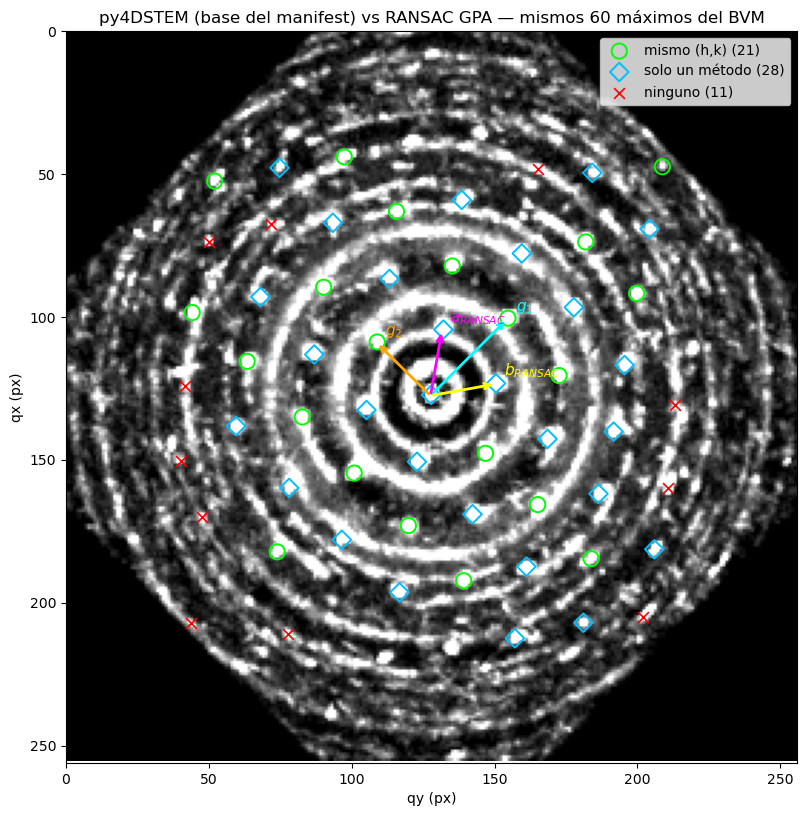

PNG comparación: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook\notebooks\output\bvm_vs_ransac_overlay.png


In [15]:
# 8.4 Tabla y figura de comparación + export
g_mag_A = np.hypot(gx_A, gy_A)
with np.errstate(divide="ignore"):
    d_A = np.where(g_mag_A > 0, 1.0 / g_mag_A, np.inf)
cmp_table = pd.DataFrame({
    "qx": qx, "qy": qy,
    "gx_A_inv": gx_A, "gy_A_inv": gy_A, "g_mag_A_inv": g_mag_A, "d_A": d_A,
    "h_py4dstem": h, "k_py4dstem": k, "residual_py4dstem_px": residual, "ok_py4dstem": indexed_ok,
    "m_ransac": mn[:, 0], "n_ransac": mn[:, 1],
    "residual_ransac_px": res_r, "residual_ransac_A_inv": res_r * Q_PIXEL, "ok_ransac": ok_r,
    "h_ransac_en_base_g1g2": hk_from_r[:, 0], "k_ransac_en_base_g1g2": hk_from_r[:, 1],
    "acuerdo": np.where(both, np.where(agree, "mismo (h,k)", "distinto"),
               np.where(indexed_ok | ok_r, "solo un método", "ninguno")),
})
cmp_csv = OUTPUT_DIR / "bvm_vs_ransac_indexing.csv"
cmp_table.to_csv(cmp_csv, index=False)
print("CSV comparación:", cmp_csv)
print(cmp_table["acuerdo"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(9.5, 9.5))
ax.imshow(disp, cmap="gray")
cat_style = {
    "mismo (h,k)": dict(marker="o", s=120, facecolors="none", edgecolors="lime", linewidths=1.4),
    "distinto": dict(marker="s", s=120, facecolors="none", edgecolors="orange", linewidths=1.6),
    "solo un método": dict(marker="D", s=90, facecolors="none", edgecolors="deepskyblue", linewidths=1.4),
    "ninguno": dict(marker="x", s=60, c="red", linewidths=1.2),
}
for cat, style in cat_style.items():
    m = (cmp_table["acuerdo"] == cat).to_numpy()
    if m.any():
        ax.scatter(qy_abs[m], qx_abs[m], label=f"{cat} ({int(m.sum())})", **style)
for gvec, name, color in ((g1, "$g_1$", "cyan"), (g2, "$g_2$", "orange"),
                          (a_r, "$a_{RANSAC}$", "magenta"), (b_r, "$b_{RANSAC}$", "yellow")):
    ax.annotate("", xy=(origin_q[1] + gvec[1], origin_q[0] + gvec[0]),
                xytext=(origin_q[1], origin_q[0]),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.0))
    ax.annotate(name, (origin_q[1] + gvec[1], origin_q[0] + gvec[0]), xytext=(6, 6),
                textcoords="offset points", color=color, fontsize=11, fontweight="bold")
ax.set_title("py4DSTEM (base del manifest) vs RANSAC GPA — mismos 60 máximos del BVM")
ax.set_xlabel("qy (px)")
ax.set_ylabel("qx (px)")
ax.legend(loc="upper right")
ax.set_xlim(0, bvm_cal.shape[1])
ax.set_ylim(bvm_cal.shape[0], 0)
fig.savefig(OUTPUT_DIR / "bvm_vs_ransac_overlay.png", dpi=200, bbox_inches="tight")
plt.show()
print("PNG comparación:", OUTPUT_DIR / "bvm_vs_ransac_overlay.png")

### Conclusión de la comparación

- **Mismo principio de asignación**: ambos indexadores resuelven `B·(h,k) ≈ g_medido` y redondean al
  entero. En los picos donde ambos indexan, los índices coinciden exactamente tras el cambio de base
  (21/21 en este run).
- **Hallazgo real de la comparación**: el RANSAC del GPA encuentra la **celda primitiva** del BVM
  (`|a| ≈ |b| ≈ 23.1 px`, ~70°) e indexa 48/60 máximos. La base del manifest (g1/g2 del pick manual
  del run real) cumple `g1 = a + b`, `g2 = a − b` con `det(M) = −2`: es una **sub-red de índice 2**
  (solo las reflexiones con h+k par en el marco primitivo), y por eso indexa 22/60. No es un error de
  ninguno de los dos — el pick manual eligió reflexiones más intensas/separadas para strain, mientras
  el RANSAC optimiza cobertura con los vectores más cortos. Si en el futuro se quisiera indexar *todo*
  el BVM en Fast4D, la base primitiva del RANSAC es la elección correcta; para reproducir el strain
  del run real, la base del manifest es la que manda.
- **Diferencia de flujo**: Fast4D/py4DSTEM fija la base con índices elegidos por el usuario
  (reproducible contra la GUI, objetivo de este notebook); el GPA la encuentra automáticamente con
  RANSAC + reducción de Gauss, útil cuando no hay pick previo.
- **Contrato de unidades resuelto para la futura `pipeline.index_bvm_peaks_step`**: las coordenadas
  físicas salen de `braggpeaks.calibration.get_Q_pixel_size()/get_Q_pixel_units()` (nunca de un valor
  suelto), la tolerancia física es `max_peak_spacing × Q_pixel_size`, y la salida reporta ambos
  espacios (px del BVM para overlay/GUI, Å⁻¹ y d[Å] para ciencia). Si la calibración de elipse
  estuviera hecha, el mismo puente aplica sobre las coordenadas ya corregidas del BVM `cal`.
- **Lo que el GPA añade y aquí no aplica**: matching contra la fase cristalina ((hkl) 3D, zone axis,
  `d_exp` vs `d_theo`). Para tenerlo en Fast4D haría falta la celda del material (p.ej. CIF), y sería
  la extensión natural de la futura `pipeline.index_bvm_peaks_step`.

## 9. De (h,k) a (hkl): zone axis [110]

**¿Por qué la indexación BVM usa 2 índices y no 3?** El BVM es la zona de Laue de orden cero (ZOLZ):
el corte 2D del espacio recíproco perpendicular al haz. Solo aparecen reflexiones que cumplen la
**ley de zona de Weiss** `h·u + k·v + l·w = 0` con `[uvw]` = zone axis. Esas reflexiones forman una
red 2D generada por dos vectores base, así que cada pico queda descrito por 2 coeficientes enteros
`(h,k)`. El tercer índice no se pierde: se recupera asignando índices de Miller 3D `G1, G2` a los dos
vectores base — entonces `hkl = h·G1 + k·G2` y la ley de zona se cumple automáticamente.

Marco del cristal (usuario): **z = [110] (zone axis)**, x = [00-1], y = [-110]. Cristal: Si cúbico
(a = 5.4309 Å, el mismo del notebook FFT del GPA). Con eso:

- zona [110] → ZOLZ = reflexiones con `h + k = 0`
- la base manual del manifest resulta ser **g1 = {220}** (dirección y = [-110]) y **g2 = (002)**
  (dirección x = [00-1]), ortogonales
- la base primitiva del RANSAC son las **{111}** (d teórico 3.135 Å, 70.53° — medimos 3.11/3.13 Å,
  70.0°), y `g1 = a+b`, `g2 = a−b` con det −2 es exactamente la relación (2-20) = (1-11)+(1-1-1),
  (002) = (1-11)−(1-1-1): la "sub-red de índice 2" de la sección 8 era la firma del diamante en [110]

Nota: (002) es cinemáticamente prohibida en la estructura diamante y aparece por doble difracción —
totalmente normal en patrones [110] de Si.

**Anclaje absoluto (9.2).** Un patrón 2D aislado no distingue +g de −g (ley de Friedel), pero aquí el
usuario conoce la orientación real de la muestra en la imagen virtual: horizontal (izq→der, +ry) =
**[0 0 -1]** y vertical (arriba→abajo, +rx) = **[-1 1 0]**, con el haz a lo largo de z = **[110]**.
La rotación QR de la calibración (135°, la que Fast4D usa para strain) es el mapa entre los ejes R del
scan y los ejes Q del detector, así que basta rotar esas direcciones reales al espacio Q y ver qué
vector base medido cae en cada dirección. Eso fija los signos absolutos de G1/G2 — y con ellos, la
orientación completa del cristal. El signo de la rotación (convención Q→R vs R→Q de py4DSTEM) se
determina solo: únicamente uno de ±135° alinea *ambos* ejes con la familia correcta de d-spacing.

In [16]:
# 9.1 Cristal + zone axis -> asignar índices 3D (G1, G2) a la base medida
A_LATTICE = 5.4309                       # Å — Si; edita si el material es otro
ZONE_AXIS = np.array([1, 1, 0])          # z del usuario (zone axis)
X_AXIS, Y_AXIS = np.array([0, 0, -1]), np.array([-1, 1, 0])   # marco del usuario (referencia)

g1_A_vec, g2_A_vec = g1 * Q_PIXEL, g2 * Q_PIXEL   # base manual en Å^-1

def _ang(u, v):
    c = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return float(np.degrees(np.arccos(np.clip(c, -1.0, 1.0))))

# Enumerar la ZOLZ (ley de zona de Weiss) hasta índice 4
rng4 = range(-4, 5)
zolz = np.array([
    (hh, kk, ll)
    for hh in rng4 for kk in rng4 for ll in rng4
    if (hh, kk, ll) != (0, 0, 0) and hh * ZONE_AXIS[0] + kk * ZONE_AXIS[1] + ll * ZONE_AXIS[2] == 0
])
g_theo = np.linalg.norm(zolz, axis=1) / A_LATTICE   # cúbico: |g| = sqrt(h²+k²+l²)/a

# Mejor pareja (G1,G2): match de |g|, del ángulo entre bases y de la quiralidad medida
meas_ang = _ang(g1_A_vec, g2_A_vec)
meas_chir = np.sign(g1[0] * g2[1] - g1[1] * g2[0])
mag1, mag2 = np.hypot(*g1_A_vec), np.hypot(*g2_A_vec)
best = None
for i1 in np.argsort(np.abs(g_theo - mag1))[:8]:
    for i2 in np.argsort(np.abs(g_theo - mag2))[:8]:
        G1c, G2c = zolz[i1].astype(float), zolz[i2].astype(float)
        cr = np.cross(G1c, G2c)
        if np.linalg.norm(cr) < 1e-9:
            continue  # colineales
        cost = (abs(g_theo[i1] - mag1) / mag1
                + abs(g_theo[i2] - mag2) / mag2
                + abs(_ang(G1c, G2c) - meas_ang) / 90.0)
        if np.sign(np.dot(cr, ZONE_AXIS)) != meas_chir:
            cost += 0.5   # convención: quiralidad medida = cruz(G1,G2)·zona
        if best is None or cost < best[0]:
            best = (cost, zolz[i1].copy(), zolz[i2].copy())

G1_HKL, G2_HKL = best[1], best[2]

def _hkl_s(v):
    return "(" + " ".join(str(int(x)) for x in v) + ")"

d1_t, d2_t = A_LATTICE / np.linalg.norm(G1_HKL), A_LATTICE / np.linalg.norm(G2_HKL)
print(f"G1 = {_hkl_s(G1_HKL)}  d_theo={d1_t:.4f} Å   d_exp={1/mag1:.4f} Å   Δd={100*(1/mag1-d1_t)/d1_t:+.2f}%")
print(f"G2 = {_hkl_s(G2_HKL)}  d_theo={d2_t:.4f} Å   d_exp={1/mag2:.4f} Å   Δd={100*(1/mag2-d2_t)/d2_t:+.2f}%")
print(f"ángulo(G1,G2) teórico = {_ang(G1_HKL.astype(float), G2_HKL.astype(float)):.2f}°   medido = {meas_ang:.2f}°")
assert np.dot(G1_HKL, ZONE_AXIS) == 0 and np.dot(G2_HKL, ZONE_AXIS) == 0  # ley de zona
print("(asignación preliminar por magnitudes/ángulo — los signos absolutos se anclan en 9.2)")

G1 = (-2 2 0)  d_theo=1.9201 Å   d_exp=1.9036 Å   Δd=-0.86%
G2 = (0 0 2)  d_theo=2.7155 Å   d_exp=2.7338 Å   Δd=+0.67%
ángulo(G1,G2) teórico = 90.00°   medido = 90.51°
(asignación preliminar por magnitudes/ángulo — los signos absolutos se anclan en 9.2)


In [17]:
# 9.2 Anclaje absoluto: marco real del usuario + rotación QR de la calibración
# Imagen virtual (espacio real, array [rx, ry]): horizontal (izq→der) = +ry = [0 0 -1];
# vertical (arriba→abajo) = +rx = [-1 1 0]. Haz a lo largo de z = [110].
REAL_AXES = [
    (np.array([0, 0, -1]), np.array([0.0, 1.0]), "horizontal (+ry)"),
    (np.array([-1, 1, 0]), np.array([1.0, 0.0]), "vertical (+rx)"),
]
theta_deg = float(bp.calibration.get_QR_rotation_degrees())
qr_flip = bool(bp.calibration.get_QR_flip())
assert not qr_flip, "QR_flip=True no contemplado en este anclaje"
print(f"QR rotation (calibración) = {theta_deg}°   flip = {qr_flip}")

# candidatos medidos: ±g1, ±g2 (px del BVM) con su |g| físico
meas_basis = [(g1, mag1, "g1"), (-g1, mag1, "-g1"), (g2, mag2, "g2"), (-g2, mag2, "-g2")]

def _match_axis(q_hat, dir3):
    """Mejor vector base medido alineado con q_hat cuya |g| sea un orden entero de dir3."""
    cands = []
    for vec, mag, vname in meas_basis:
        n = mag * A_LATTICE / np.linalg.norm(dir3)   # orden de la reflexión en esa dirección
        if abs(n - round(n)) < 0.1 and 1 <= round(n) <= 4:
            cands.append((_ang(q_hat, vec), vname, vec, int(round(n))))
    cands.sort(key=lambda t: t[0])
    return cands[0] if cands else None

solution = None
for s in (+1, -1):
    th = np.radians(s * theta_deg)
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    matches, ok = [], True
    for dir3, r_hat, label in REAL_AXES:
        m = _match_axis(R @ r_hat, dir3)
        if m is None or m[0] > 5.0:
            ok = False
            break
        matches.append((dir3, label, m))
    if ok:
        solution = (s, matches)
        break
assert solution is not None, "ningún signo de rotación QR alinea ambos ejes — revisa el marco real"

s, matches = solution
print(f"convención resuelta empíricamente: q̂ = Rot({'+' if s > 0 else '−'}{theta_deg:g}°) · r̂ "
      "(solo este signo alinea ambos ejes con la familia d correcta)")
anchored = {}
for dir3, label, (ang_err, vname, vec, n) in matches:
    G_spot = n * dir3 if not vname.startswith("-") else -n * dir3   # hkl del spot en +g1 / +g2
    anchored[vname.lstrip("-")] = G_spot
    print(f"  {label} = [{dir3[0]} {dir3[1]} {dir3[2]}] → {vname} (desvío {ang_err:.2f}°) "
          f"⇒ el spot en +{vname.lstrip('-')} es {_hkl_s(G_spot)}")
assert set(anchored) == {"g1", "g2"}, "los dos ejes reales deben mapear a g1 y g2"

G1_anch, G2_anch = anchored["g1"].astype(int), anchored["g2"].astype(int)
if not (np.array_equal(G1_anch, G1_HKL) and np.array_equal(G2_anch, G2_HKL)):
    print(f"\nanclaje físico ({_hkl_s(G1_anch)}, {_hkl_s(G2_anch)}) difiere de la convención 9.1 "
          f"({_hkl_s(G1_HKL)}, {_hkl_s(G2_HKL)}) — se adopta el anclaje físico")
G1_HKL, G2_HKL = G1_anch, G2_anch
assert np.dot(G1_HKL, ZONE_AXIS) == 0 and np.dot(G2_HKL, ZONE_AXIS) == 0

# Índices 3D de la base primitiva del RANSAC: [A B] = [G1 G2]·M^-1 — deben salir ENTEROS
AB = np.column_stack([G1_HKL, G2_HKL]).astype(float) @ np.linalg.inv(M_int.astype(float))
assert np.allclose(AB, np.round(AB)), "la base primitiva no es entera en hkl — revisa G1/G2"
A_HKL, B_HKL = np.round(AB[:, 0]).astype(int), np.round(AB[:, 1]).astype(int)
dA_t, dB_t = A_LATTICE / np.linalg.norm(A_HKL), A_LATTICE / np.linalg.norm(B_HKL)
print(f"\nbase final anclada:  g1 = {_hkl_s(G1_HKL)}   g2 = {_hkl_s(G2_HKL)}")
print(f"a (RANSAC) = {_hkl_s(A_HKL)}  d_theo={dA_t:.4f} Å   d_exp={1/np.hypot(*a_A):.4f} Å")
print(f"b (RANSAC) = {_hkl_s(B_HKL)}  d_theo={dB_t:.4f} Å   d_exp={1/np.hypot(*b_A):.4f} Å")
print("-> orientación del cristal completamente definida por el marco real del usuario.")

QR rotation (calibración) = 135.0°   flip = False
convención resuelta empíricamente: q̂ = Rot(+135°) · r̂ (solo este signo alinea ambos ejes con la familia d correcta)
  horizontal (+ry) = [0 0 -1] → g2 (desvío 0.52°) ⇒ el spot en +g2 es (0 0 -2)
  vertical (+rx) = [-1 1 0] → g1 (desvío 0.01°) ⇒ el spot en +g1 es (-2 2 0)

anclaje físico ((-2 2 0), (0 0 -2)) difiere de la convención 9.1 ((-2 2 0), (0 0 2)) — se adopta el anclaje físico

base final anclada:  g1 = (-2 2 0)   g2 = (0 0 -2)
a (RANSAC) = (-1 1 -1)  d_theo=3.1355 Å   d_exp=3.1080 Å
b (RANSAC) = (-1 1 1)  d_theo=3.1355 Å   d_exp=3.1291 Å
-> orientación del cristal completamente definida por el marco real del usuario.


In [18]:
# 9.2 (hkl) por pico vía la base primitiva (cubre 48/60) + validaciones
hkl_all = mn @ np.stack([A_HKL, B_HKL])          # (60,3): hkl = m·A + n·B
zone_law = hkl_all @ ZONE_AXIS
assert np.all(zone_law[ok_r] == 0), "hay picos indexados que violan la ley de zona"

# Cross-check: donde la base manual también indexa, h·G1 + k·G2 debe dar el MISMO hkl
hkl_manual = np.stack([h, k], axis=1) @ np.stack([G1_HKL, G2_HKL])
assert np.all(hkl_all[both] == hkl_manual[both]), "hkl inconsistente entre base manual y primitiva"

# d_exp vs d_theo por pico (excluye el origin)
norm_hkl = np.linalg.norm(hkl_all, axis=1)
sel = ok_r & (norm_hkl > 0)
with np.errstate(divide="ignore"):
    d_theo_pk = A_LATTICE / np.where(norm_hkl > 0, norm_hkl, np.inf)
    d_exp_pk = np.where(g_mag_A > 0, 1.0 / g_mag_A, np.inf)
    dd_pct = 100.0 * (d_exp_pk - d_theo_pk) / d_theo_pk
print(f"picos con hkl asignado: {int(sel.sum())} (+ origin) de 60")
print(f"Δd por pico: media={np.mean(np.abs(dd_pct[sel])):.2f}%  máx={np.max(np.abs(dd_pct[sel])):.2f}%")
worst = np.flatnonzero(sel & (np.abs(dd_pct) > 2.0))
if worst.size:
    print("picos con |Δd| > 2% (la tolerancia de 2 px pesa más en |g| chicos; inspeccionar):")
    for i in worst:
        print(f"  hkl={_hkl_s(hkl_all[i])}  d_exp={d_exp_pk[i]:.3f} Å  "
              f"d_theo={d_theo_pk[i]:.3f} Å  Δd={dd_pct[i]:+.2f}%  residual={res_r[i]:.2f} px")
assert np.max(np.abs(dd_pct[sel])) < 5.0, "algún pico difiere >5% del d teórico — revisa cristal/calibración"

hkl_str = np.array(["(" + " ".join(str(int(v)) for v in row) + ")" for row in hkl_all])
hkl_table = pd.DataFrame({
    "qx": qx, "qy": qy, "g_mag_A_inv": g_mag_A,
    "m": mn[:, 0], "n": mn[:, 1],
    "h3": hkl_all[:, 0], "k3": hkl_all[:, 1], "l3": hkl_all[:, 2],
    "d_exp_A": d_exp_pk, "d_theo_A": d_theo_pk, "dd_pct": dd_pct,
    "zone_law": zone_law, "bvm_intensity": bvm_intensity, "ok": ok_r,
}).sort_values("bvm_intensity", ascending=False).reset_index(drop=True)
hkl_csv = OUTPUT_DIR / "indexed_bvm_peaks_hkl.csv"
hkl_table.to_csv(hkl_csv, index=False)
print("CSV:", hkl_csv)
hkl_table[hkl_table["ok"]].head(12)

picos con hkl asignado: 48 (+ origin) de 60
Δd por pico: media=1.00%  máx=4.32%
picos con |Δd| > 2% (la tolerancia de 2 px pesa más en |g| chicos; inspeccionar):
  hkl=(1 -1 1)  d_exp=3.064 Å  d_theo=3.136 Å  Δd=-2.30%  residual=0.81 px
  hkl=(0 0 2)  d_exp=2.598 Å  d_theo=2.715 Å  Δd=-4.32%  residual=1.38 px
  hkl=(-1 1 -1)  d_exp=3.069 Å  d_theo=3.136 Å  Δd=-2.11%  residual=0.55 px
  hkl=(1 -1 -3)  d_exp=1.675 Å  d_theo=1.637 Å  Δd=+2.31%  residual=0.89 px
CSV: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook\notebooks\output\indexed_bvm_peaks_hkl.csv


,qx,qy,g_mag_A_inv,m,n,h3,k3,l3,d_exp_A,d_theo_A,dd_pct,zone_law,bvm_intensity,ok
1,23.129823,-4.753433,0.326423,-1,0,1,-1,1,3.063506,3.135532,-2.297079,0,2.769586e+06,True
2,-4.319725,22.899936,0.322146,0,1,-1,1,1,3.104181,3.135532,-0.999840,0,2.565778e+06,True
3,20.151851,19.214388,0.384909,-1,1,0,0,2,2.598016,2.715450,-4.324670,0,2.180513e+06,True
4,-23.136570,4.486366,0.325792,1,0,-1,1,-1,3.069445,3.135532,-2.107680,0,1.870917e+06,True
5,5.015152,-22.422653,0.317624,0,-1,1,-1,-1,3.148378,3.135532,0.409695,0,1.865328e+06,True
6,-18.812051,-18.675506,0.366439,1,-1,0,0,-2,2.728970,2.715450,0.497900,0,1.832058e+06,True
7,-27.147482,27.068813,0.529958,1,1,-2,2,0,1.886942,1.920113,-1.727568,0,1.730195e+06,True
8,41.477684,14.692686,0.608288,-2,1,1,-1,3,1.643957,1.637478,0.395679,0,1.602306e+06,True
9,-14.414026,-40.705071,0.596935,1,-2,1,-1,-3,1.675225,1.637478,2.305202,0,1.486182e+06,True
10,27.075113,-26.735784,0.526005,-1,-1,2,-2,0,1.901122,1.920113,-0.989071,0,1.325232e+06,True


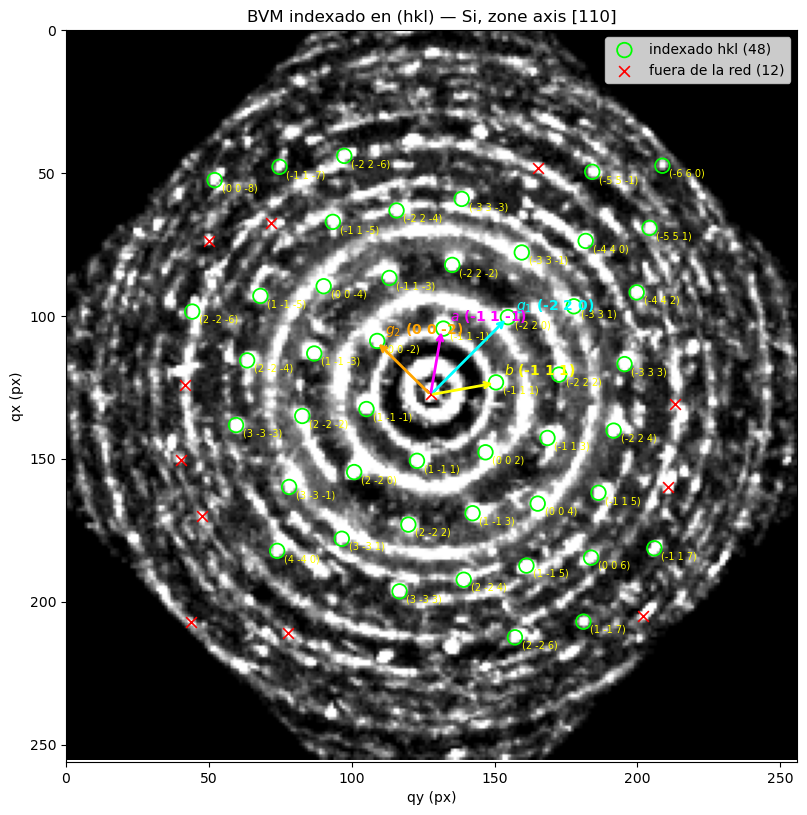

PNG: C:\Users\jtapiaca.ASURITE\Fast4d\.claude\worktrees\peak-indexer-notebook\notebooks\output\bvm_indexed_hkl_overlay.png


In [19]:
# 9.3 Overlay con etiquetas (hkl) completas
fig, ax = plt.subplots(figsize=(9.5, 9.5))
ax.imshow(disp, cmap="gray")
ax.scatter(qy_abs[ok_r], qx_abs[ok_r], s=110, facecolors="none", edgecolors="lime",
           linewidths=1.3, label=f"indexado hkl ({int(ok_r.sum())})")
if (~ok_r).any():
    ax.scatter(qy_abs[~ok_r], qx_abs[~ok_r], s=60, marker="x", c="red",
               linewidths=1.2, label=f"fuera de la red ({int((~ok_r).sum())})")
for i in np.flatnonzero(ok_r):
    ax.annotate(hkl_str[i], (qy_abs[i], qx_abs[i]), xytext=(5, -8),
                textcoords="offset points", color="yellow", fontsize=7)
for gvec, name, color in ((g1, f"$g_1$ {_hkl_s(G1_HKL)}", "cyan"),
                          (g2, f"$g_2$ {_hkl_s(G2_HKL)}", "orange"),
                          (a_r, f"$a$ {_hkl_s(A_HKL)}", "magenta"),
                          (b_r, f"$b$ {_hkl_s(B_HKL)}", "yellow")):
    ax.annotate("", xy=(origin_q[1] + gvec[1], origin_q[0] + gvec[0]),
                xytext=(origin_q[1], origin_q[0]),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.0))
    ax.annotate(name, (origin_q[1] + gvec[1], origin_q[0] + gvec[0]), xytext=(6, 6),
                textcoords="offset points", color=color, fontsize=10, fontweight="bold")
ax.set_title(f"BVM indexado en (hkl) — Si, zone axis [{ZONE_AXIS[0]}{ZONE_AXIS[1]}{ZONE_AXIS[2]}]")
ax.set_xlabel("qy (px)")
ax.set_ylabel("qx (px)")
ax.legend(loc="upper right")
ax.set_xlim(0, bvm_cal.shape[1])
ax.set_ylim(bvm_cal.shape[0], 0)
fig.savefig(OUTPUT_DIR / "bvm_indexed_hkl_overlay.png", dpi=200, bbox_inches="tight")
plt.show()
print("PNG:", OUTPUT_DIR / "bvm_indexed_hkl_overlay.png")